In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [12]:


df = pd.read_csv(r'../../../Datasets/titanic.csv')

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [14]:
new_df = df[['Age', 'Fare', 'Survived']]

new_df

,Age,Fare,Survived
0,34.5,7.8292,0
1,47.0,7.0000,1
2,62.0,9.6875,0
3,27.0,8.6625,0
4,22.0,12.2875,1
...,...,...,...
413,NaN,8.0500,0
414,39.0,108.9000,1
415,38.5,7.2500,0
416,NaN,8.0500,0


In [15]:
new_df['Family'] = df['SibSp'] + df['Parch']



C:\Users\Muhammad Awais Raza\AppData\Local\Temp\ipykernel_5380\4183551603.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['Family'] = df['SibSp'] + df['Parch']


In [16]:
new_df

,Age,Fare,Survived,Family
0,34.5,7.8292,0,0
1,47.0,7.0000,1,1
2,62.0,9.6875,0,0
3,27.0,8.6625,0,0
4,22.0,12.2875,1,2
...,...,...,...,...
413,NaN,8.0500,0,0
414,39.0,108.9000,1,0
415,38.5,7.2500,0,0
416,NaN,8.0500,0,0


In [17]:
new_df.isnull().mean()

Age         0.205742
Fare        0.002392
Survived    0.000000
Family      0.000000
dtype: float64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(new_df.drop(columns=['Survived']), new_df['Survived'], test_size=0.2, random_state=False)



In [20]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Age'].mean()
median_fare = X_train['Age'].median()

In [19]:
X_train

,Age,Fare,Family
20,55.0,59.4000,1
306,30.0,151.5500,3
142,61.0,262.3750,4
14,47.0,61.1750,1
284,2.0,20.2125,2
...,...,...,...
323,33.0,26.5500,0
192,11.5,14.5000,2
117,1.0,16.7000,2
47,NaN,7.7500,0


In [21]:
X_train['Mean_age'] = X_train['Age'].fillna(mean_age)
X_train['Median_age'] = X_train['Age'].fillna(median_age)

X_train['Mean_fare'] = X_train['Fare'].fillna(mean_fare)
X_train['Median_fare'] = X_train['Fare'].fillna(median_fare)

In [22]:
X_train.sample(5)

,Age,Fare,Family,Mean_age,Median_age,Mean_fare,Median_fare
112,36.0,31.6792,0,36.00000,36.0,31.6792,31.6792
197,18.0,7.7750,0,18.00000,18.0,7.7750,7.7750
403,17.0,47.1000,0,17.00000,17.0,47.1000,47.1000
290,NaN,39.6000,0,30.42037,28.0,39.6000,39.6000
36,NaN,8.0500,0,30.42037,28.0,8.0500,8.0500


In [24]:
print('Orignal age variance: ', X_train['Age'].var())
print('after mean impute age variance: ', X_train['Mean_age'].var())
print('after median impute age variance: ', X_train['Median_age'].var())

print('Orignal fare variance: ', X_train['Fare'].var())
print('after mean impute fare variance: ', X_train['Mean_fare'].var())
print('after median impute fare variance: ', X_train['Median_fare'].var())

Orignal age variance:  217.1999017210519
after mean impute age variance:  175.45577646535423
after median impute age variance:  176.36593426120734
Orignal fare variance:  3243.1394392566544
after mean impute fare variance:  3233.4682237382135
after median impute fare variance:  3233.554804323617


In [25]:
X_train.cov()

,Age,Fare,Family,Mean_age,Median_age,Mean_fare,Median_fare
Age,217.199902,319.306905,-2.005759,217.199902,217.199902,317.051481,316.780835
Fare,319.306905,3243.139439,24.929086,257.319693,266.715303,3243.139439,3243.139439
Family,-2.005759,24.929086,2.183822,-1.620268,-1.531394,24.866345,24.872503
Mean_age,217.199902,257.319693,-1.620268,175.455776,175.455776,256.116662,255.898032
Median_age,217.199902,266.715303,-1.531394,175.455776,176.365934,265.477423,265.255421
Mean_fare,317.051481,3243.139439,24.866345,256.116662,265.477423,3233.468224,3233.502744
Median_fare,316.780835,3243.139439,24.872503,255.898032,265.255421,3233.502744,3233.554804


<Axes: >

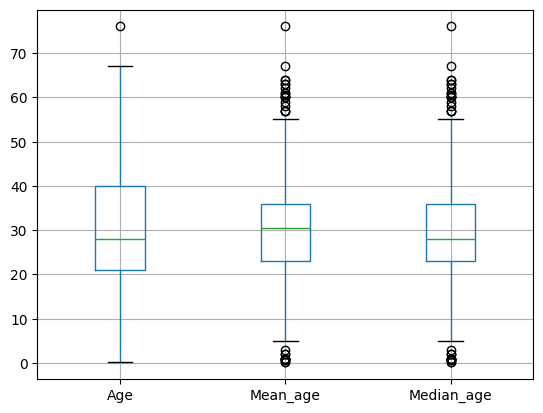

In [27]:
X_train[['Age', 'Mean_age', 'Median_age']].boxplot()

### Using sklearn


In [45]:
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer

imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

trf = make_column_transformer(
    (imputer1, ['Fare']),
    (imputer2, ['Age']),
    remainder='passthrough'   # Keep other columns unchanged
)

In [48]:
# Apply manual imputation to X_test to match X_train columns
X_test['Mean_age'] = X_test['Age'].fillna(mean_age)
X_test['Median_age'] = X_test['Age'].fillna(median_age)
X_test['Mean_fare'] = X_test['Fare'].fillna(mean_fare)
X_test['Median_fare'] = X_test['Fare'].fillna(median_fare)

# Now fit and transform both datasets
trf.fit(X_train)
X_train_transformed =  trf.transform(X_train)
X_test_transformed = trf.transform(X_test)